# 04. 내구성 실행 (Durable Execution)

> 프로덕션 에이전트는 도중에 죽어도 다시 살아나야 해요. 체크포인터 기반 복원, `RetryPolicy`, 멱등성 키로 내구성 있는 실행 계층을 만들어요.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. 내구성 실행(Durable Execution)의 3가지 핵심 요소를 설명하고 직접 구성할 수 있어요
2. 3가지 Durability Mode(exit, async, sync)의 차이를 이해하고 상황에 맞게 선택할 수 있어요
3. 장애 상황을 시뮬레이션하고 같은 thread_id로 그래프 실행을 재개할 수 있어요
4. RetryPolicy를 설정하여 일시적인 오류에 자동으로 재시도하는 그래프를 만들 수 있어요
5. @task + @entrypoint 패턴으로 사이드 이펙트를 격리하는 Functional API를 작성할 수 있어요

## 사전 지식

- `03-Branching-Parallel.ipynb`: Conditional Edges, 병렬 실행, Fan-out/Fan-in 패턴
- Part 2에서 배운 Checkpointer(InMemorySaver, SqliteSaver)와 thread_id 개념
- StateGraph의 노드·엣지 구성 방식

## 내구성 실행이란?

에이전트 워크플로우를 프로덕션에서 실행하다 보면 반드시 **중간에 실패하는 경우**가 생겨요.
네트워크 오류, API 속도 제한(Rate Limit), 서버 재시작 등 다양한 이유로 그래프 실행이 중단될 수 있죠.

**내구성 실행(Durable Execution)**은 이런 상황에서도 **처음부터 다시 시작하지 않고**, 중단된 지점에서 이어갈 수 있게 해주는 기능이에요.

### 왜 필요한가요?

온라인 쇼핑을 하다가 결제 직전에 인터넷이 끊겼다고 상상해보세요. 다시 접속했을 때 장바구니가 비어있으면 처음부터 다시 담아야 해요. 하지만 장바구니가 **저장**되어 있으면 결제만 다시 하면 되죠. 내구성 실행이 바로 이런 역할을 해요.

> 🔑 **핵심 개념**: 내구성 실행의 3가지 필수 요소
> 1. **Checkpointer**: 각 스텝의 상태를 저장하는 저장소 (InMemorySaver, SqliteSaver, PostgresSaver)
> 2. **thread_id**: 동일한 실행 흐름을 식별하는 고유 ID
> 3. **결정론성(Determinism)**: 재개 시 동일한 경로로 흐르도록 랜덤/사이드 이펙트를 @task 안에 격리

```mermaid
flowchart TD
    A["그래프 실행 시작<br/>thread_id: abc-123"] --> B["Node 1 실행<br/>체크포인트 저장"]
    B --> C["Node 2 실행<br/>체크포인트 저장"]
    C --> D{"Node 3 실행 중<br/>장애 발생!"}
    D --> E["graph.invoke(None, config)<br/>같은 thread_id로 재개"]
    E --> F["Node 3부터 재시작<br/>(Node 1, 2는 건너뜀)"]
    F --> G["Node 4 실행<br/>완료"]

    classDef ok fill:#d4edda,stroke:#28a745,color:#155724
    classDef fail fill:#f8d7da,stroke:#dc3545,color:#721c24
    classDef resume fill:#cce5ff,stroke:#007bff,color:#004085
    classDef storage fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e

    class A,B,C ok
    class D fail
    class E,F resume
    class G ok
```

### Durability Mode 비교

| Mode | 체크포인트 생성 시점 | 사용 상황 | 비유 |
|------|------------------|-----------|------|
| `"exit"` (기본값) | 노드 완료 시 | 일반적인 사용, 대부분의 경우 적합 | 각 역 도착 시 기록 |
| `"async"` | 비동기 작업 완료 시 | 오래 걸리는 비동기 작업이 있을 때 | 비동기 작업마다 기록 |
| `"sync"` | 모든 스텝마다 | 최대 내구성 필요, 중단점이 많을수록 재개가 세밀해짐 | 매 발걸음마다 기록 |

### Super-step과 트랜잭션 보장

> 🔑 **핵심 개념**: Super-step은 체크포인트 생성 단위예요.
> 하나의 Super-step 안에서 여러 노드가 실행될 수 있어요.
> 만약 Super-step 중간에 실패하면 **해당 Super-step 전체가 롤백**되어, 이전 체크포인트에서 재개돼요.
> 이는 데이터베이스 트랜잭션과 유사한 "all-or-nothing" 보장을 제공해요.

## 환경 설정

In [1]:
# ---------------------------------------------------
# 환경 변수 로드
# ---------------------------------------------------
from dotenv import load_dotenv

load_dotenv()


True

In [2]:
# ---------------------------------------------------
# LangSmith 추적 설정 (선택 사항)
# ---------------------------------------------------
# 실행 과정을 LangSmith에서 시각적으로 확인할 수 있어요
import os

# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-04-Durable-Execution"


## 1. 기본 내구성 실행 - 장애 시뮬레이션과 재개

먼저 가장 기본적인 내구성 실행 패턴을 살펴볼게요.
세 개의 노드로 구성된 간단한 그래프에서 두 번째 노드가 실패하는 상황을 만들고,
같은 `thread_id`로 재개해볼 거예요.

> 🎯 **강의 포인트**: `graph.invoke(None, config)`에서 **None**을 입력으로 넘기는 것이 핵심이에요.
> None은 "새 입력 없이 기존 체크포인트에서 이어가라"는 신호예요.
> 같은 thread_id를 사용하면 LangGraph가 자동으로 마지막 체크포인트를 찾아 재개해요.

In [ ]:
# ---------------------------------------------------
# 기본 내구성 실행 그래프 구성
# ---------------------------------------------------
# TypedDict: 그래프 상태 타입 정의
# Annotated: 리듀서 함수 연결
# add_messages: 메시지 목록에 새 메시지를 추가하는 리듀서
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from IPython.display import Image, display

# 그래프 상태 정의
class WorkflowState(TypedDict):
    step: int          # 현재 실행 단계
    result: list[str]  # 각 단계의 처리 결과

# 장애 발생 여부를 제어하는 전역 플래그
fail_at_step2 = True


def step1(state: WorkflowState) -> WorkflowState:
    """1단계: 데이터 수집 노드"""
    #   [Step 1] 데이터 수집 중...
    return {
        "step": 1,
        "result": state["result"] + ["Step1: 데이터 수집 완료"]
    }


def step2(state: WorkflowState) -> WorkflowState:
    """2단계: 데이터 처리 노드 (장애 시뮬레이션 가능)"""
    global fail_at_step2
    #   [Step 2] 데이터 처리 중...

    if fail_at_step2:
        # 처음 실행 시 장애 시뮬레이션
        fail_at_step2 = False  # 다음 재시도 시에는 성공
        raise RuntimeError("Step 2: 네트워크 오류 발생! (시뮬레이션)")

    return {
        "step": 2,
        "result": state["result"] + ["Step2: 데이터 처리 완료"]
    }


def step3(state: WorkflowState) -> WorkflowState:
    """3단계: 결과 저장 노드"""
    #   [Step 3] 결과 저장 중...
    return {
        "step": 3,
        "result": state["result"] + ["Step3: 결과 저장 완료"]
    }


# 그래프 구성
builder = StateGraph(WorkflowState)
builder.add_node("step1", step1)
builder.add_node("step2", step2)
builder.add_node("step3", step3)

# 순차적 엣지 연결
builder.add_edge(START, "step1")
builder.add_edge("step1", "step2")
builder.add_edge("step2", "step3")
builder.add_edge("step3", END)

# InMemorySaver: 개발/테스트용 인메모리 체크포인터
# 프로덕션에서는 SqliteSaver 또는 PostgresSaver를 사용해요
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

# 그래프 흐름: START → step1 → step2 → step3 → END
# step1: 데이터를 수집해요
# step2: 데이터를 처리해요 (장애 시뮬레이션 가능)
# step3: 결과를 저장해요
# 체크포인터가 각 노드 완료 시 상태를 저장해요
display(Image(graph.get_graph().draw_mermaid_png()))


In [4]:
# ---------------------------------------------------
# 1차 실행: 의도적으로 Step 2에서 실패시키기
# ---------------------------------------------------
import uuid

# thread_id: 실행 흐름의 고유 식별자
# 같은 thread_id를 사용하면 이전 체크포인트에서 재개할 수 있어요
thread_id = str(uuid.uuid4())
config = {"configurable": {"thread_id": thread_id}}

print(f"Thread ID: {thread_id[:8]}...")
# === 1차 실행 (Step 2에서 실패 예정) ===

initial_state = {"step": 0, "result": []}

try:
    result = graph.invoke(initial_state, config)
except RuntimeError as e:
    print(f"\n오류 발생: {e}")
    # Step 1까지의 결과는 체크포인트에 저장되어 있어요.


Thread ID: b7b6c20a...

오류 발생: Step 2: 네트워크 오류 발생! (시뮬레이션)


In [5]:
# ---------------------------------------------------
# 체크포인트 상태 확인
# ---------------------------------------------------
# 장애 발생 시점까지의 상태가 저장되어 있는지 확인해요
checkpoint_state = graph.get_state(config)

# === 저장된 체크포인트 상태 ===
print(f"저장된 결과: {checkpoint_state.values.get('result', [])}")
print(f"현재 단계: {checkpoint_state.values.get('step', 0)}")
print(f"다음 실행 노드: {checkpoint_state.next}")


저장된 결과: ['Step1: 데이터 수집 완료']
현재 단계: 1
다음 실행 노드: ('step2',)


In [6]:
# ---------------------------------------------------
# 2차 실행: None 입력으로 중단 지점에서 재개
# ---------------------------------------------------
# None을 입력으로 전달하면 "새 입력 없이 기존 체크포인트에서 이어가라"는 의미예요
# 같은 thread_id를 사용하므로 Step 2부터 재개돼요
# === 2차 실행 (Step 2부터 재개) ===

result = graph.invoke(None, config)  # None: 새 입력 없이 체크포인트에서 재개

# === 최종 결과 ===
for r in result["result"]:
    print(f"  {r}")
print(f"\nStep 1은 다시 실행되지 않았어요! (체크포인트에서 건너뜀)")


  Step1: 데이터 수집 완료
  Step2: 데이터 처리 완료
  Step3: 결과 저장 완료

Step 1은 다시 실행되지 않았어요! (체크포인트에서 건너뜀)


> 💡 **실무 팁**: 실제 프로덕션에서는 `try-except` 블록으로 오류를 잡아 로그에 기록하고,
> 별도의 재시도 로직(큐, 스케줄러 등)이 같은 `thread_id`로 `graph.invoke(None, config)`를 호출해요.
> LangGraph는 마지막 성공 체크포인트를 자동으로 찾아 재개하므로 재시작 로직이 단순해져요.

### Checkpointer 종류와 선택 기준

| Checkpointer | 저장 위치 | 사용 환경 | 설치 |
|-------------|---------|---------|------|
| `InMemorySaver` | 메모리 | 개발/테스트 | 기본 포함 |
| `SqliteSaver` | SQLite 파일 | 로컬/소규모 | `langgraph-checkpoint-sqlite` |
| `PostgresSaver` | PostgreSQL DB | 프로덕션 | `langgraph-checkpoint-postgres` |

## 2. RetryPolicy - 자동 재시도

### 왜 수동 재개 대신 자동 재시도가 필요한가요?

섹션 1에서는 장애 발생 후 수동으로 `graph.invoke(None, config)`를 호출해서 재개했어요. 하지만 API 타임아웃처럼 **잠깐 기다리면 자동으로 해결되는 오류**에 매번 사람이 개입하는 것은 비효율적이에요. 마치 전화가 안 터질 때 자동으로 재다이얼하는 것처럼, LangGraph의 **RetryPolicy**를 사용하면 일시적인 오류에 자동으로 재시도할 수 있어요.

> 🔑 **핵심 개념**: RetryPolicy의 주요 파라미터
> - `max_attempts`: 최대 시도 횟수 (기본값: 3)
> - `initial_interval`: 첫 재시도 대기 시간(초)
> - `backoff_factor`: 재시도마다 대기 시간을 곱하는 배수 (지수 백오프)
> - `jitter`: 재시도 간격에 무작위 값 추가 여부 (True 권장 - 동시 요청 분산)
> - `retry_on`: 재시도할 예외 유형 또는 판별 함수

> ⚠️ **자주 하는 실수**: `ValueError`, `TypeError`, `KeyError` 같은 **프로그래밍 오류**는
> RetryPolicy가 기본적으로 재시도하지 않아요 (`default_retry_on` 제외 목록).
> 이는 의도된 동작이에요. 코드 버그를 반복 호출하면 낭비만 늘어나니까요.
> 재시도할 예외를 명시적으로 지정하거나, `retry_on` 콜백으로 세밀하게 제어할 수 있어요.

In [7]:
# ---------------------------------------------------
# RetryPolicy 설정 예시
# ---------------------------------------------------
from langgraph.types import RetryPolicy

# 기본 RetryPolicy: 3회 재시도, 지수 백오프
default_retry = RetryPolicy(
    max_attempts=3,       # 최대 3번 시도 (초기 실행 포함)
    initial_interval=0.1, # 첫 재시도 대기: 0.1초
    backoff_factor=2.0,   # 재시도마다 2배씩 대기 시간 증가 (0.1 → 0.2 → 0.4)
    jitter=True,          # 무작위 지터 추가 (동시 요청 분산)
)

# 기본 RetryPolicy 설정:
print(f"  max_attempts: {default_retry.max_attempts}")
print(f"  initial_interval: {default_retry.initial_interval}초")
print(f"  backoff_factor: {default_retry.backoff_factor}배")
print(f"  jitter: {default_retry.jitter}")
print()

# 특정 예외만 재시도하는 RetryPolicy
# retry_on에 함수를 전달하면 세밀한 제어가 가능해요
def should_retry(exc: Exception) -> bool:
    """재시도 여부를 결정하는 함수예요"""
    # ConnectionError, TimeoutError만 재시도
    return isinstance(exc, (ConnectionError, TimeoutError))

selective_retry = RetryPolicy(
    max_attempts=5,
    initial_interval=1.0,
    backoff_factor=1.5,
    retry_on=should_retry,  # 재시도 여부를 함수로 결정
)

# 선택적 RetryPolicy: ConnectionError, TimeoutError만 재시도


  max_attempts: 3
  initial_interval: 0.1초
  backoff_factor: 2.0배
  jitter: True



In [8]:
# ---------------------------------------------------
# RetryPolicy가 적용된 그래프 구성
# ---------------------------------------------------
# 불안정한 외부 API를 호출하는 시나리오를 시뮬레이션해요
import random

# 시도 횟수 추적 (실습용)
attempt_count = {"api_call": 0}


def unreliable_api_node(state: WorkflowState) -> WorkflowState:
    """불안정한 외부 API를 호출하는 노드예요"""
    attempt_count["api_call"] += 1
    current_attempt = attempt_count["api_call"]
    print(f"  [API 호출] 시도 #{current_attempt}")

    # 처음 2번은 ConnectionError 발생 (실제 API 불안정 시뮬레이션)
    if current_attempt <= 2:
        raise ConnectionError(f"API 서버 연결 실패 (시도 #{current_attempt})")

    print(f"  [API 호출] 성공!")
    return {
        "step": 1,
        "result": state["result"] + [f"API 데이터 수신 완료 (시도 #{current_attempt})"],
    }


def process_node(state: WorkflowState) -> WorkflowState:
    """데이터 처리 노드예요"""
    #   [처리] 데이터 분석 중...
    return {
        "step": 2,
        "result": state["result"] + ["데이터 처리 완료"],
    }


# RetryPolicy를 add_node 시 적용해요
retry_builder = StateGraph(WorkflowState)
retry_builder.add_node(
    "api_call",
    unreliable_api_node,
    retry=RetryPolicy(
        max_attempts=5,
        initial_interval=0.05,  # 빠른 테스트를 위해 짧게 설정
        backoff_factor=2.0,
        retry_on=lambda e: isinstance(e, ConnectionError),  # ConnectionError만 재시도
    ),
)
retry_builder.add_node("process", process_node)
retry_builder.add_edge(START, "api_call")
retry_builder.add_edge("api_call", "process")
retry_builder.add_edge("process", END)

retry_graph = retry_builder.compile(checkpointer=InMemorySaver())

# RetryPolicy가 적용된 그래프를 구성했어요.
# api_call 노드: ConnectionError 발생 시 최대 5회 재시도


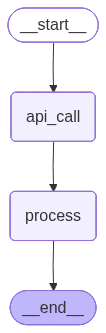

In [9]:
# 그래프 흐름: START → api_call → process → END
# api_call 노드: 외부 API를 호출해요 (ConnectionError 발생 시 최대 5회 재시도)
# process 노드: 수신된 데이터를 분석해요
display(Image(retry_graph.get_graph().draw_mermaid_png()))


In [10]:
# ---------------------------------------------------
# RetryPolicy 동작 확인
# ---------------------------------------------------
# 처음 2번은 실패하지만 RetryPolicy가 자동으로 재시도해요
retry_config = {"configurable": {"thread_id": str(uuid.uuid4())}}

# === RetryPolicy 자동 재시도 테스트 ===
result = retry_graph.invoke({"step": 0, "result": []}, retry_config)

# === 최종 결과 ===
for r in result["result"]:
    print(f"  {r}")
print(f"\n총 API 호출 시도 횟수: {attempt_count['api_call']}")


  [API 호출] 시도 #1
  [API 호출] 시도 #2
  [API 호출] 시도 #3
  [API 호출] 성공!
  API 데이터 수신 완료 (시도 #3)
  데이터 처리 완료

총 API 호출 시도 횟수: 3


> 💡 **실무 팁**: 재시도 간격을 설계할 때 **지수 백오프(exponential backoff) + 지터(jitter)** 패턴이 권장돼요.
> - 지수 백오프: 재시도할수록 대기 시간이 늘어나 서버 과부하를 방지해요
> - 지터: 무작위 변동을 추가해 여러 클라이언트가 동시에 재시도하는 '사이클 스톰'을 막아요
> - AWS, Google Cloud 등 주요 클라우드 서비스의 공식 권장 패턴이에요

## 3. 결정론성과 @task 패턴

### 왜 비교 예제가 필요한가요?

내구성 실행에서 가장 헷갈리는 지점은 **"재개(resume)는 멈춘 코드 줄에서 그대로 이어지는가?"**예요.  
정답은 **아니에요**. `interrupt()` 뒤에 `Command(resume=...)`로 재개하면 LangGraph는 체크포인트를 기준으로 실행을 다시 구성하고, Functional API에서는 중단된 `@entrypoint`의 **처음부터 replay**해요.

그래서 `interrupt()` 앞에 일반 Python 코드로 API 호출, 랜덤값 생성, 파일 쓰기 같은 사이드 이펙트를 넣으면 재개 과정에서 그 코드가 다시 실행될 수 있어요.

이번 섹션은 같은 흐름을 두 번 비교합니다.

1. ❌ **비교 대상**: `@task` 없이 API 호출을 직접 실행
2. ✅ **권장 패턴**: 같은 API 호출을 `@task`로 감싸서 결과를 체크포인트에 저장

| 패턴 | `Command(resume=...)` 시 동작 | 결과 |
|------|-----------------------------|------|
| `@entrypoint` 안에서 직접 API 호출 | `interrupt()` 이전 코드가 replay되며 API가 다시 호출됨 | 중복 호출/다른 결과 위험 |
| API 호출을 `@task`로 감싸기 | 완료된 task 결과를 체크포인트에서 읽음 | 중복 호출 방지, 같은 결과 유지 |

> 🔑 **핵심 개념**: `@task`는 "오래 걸리거나, 외부 세계를 바꾸거나, 매번 값이 달라질 수 있는 작업"을 replay-safe하게 만드는 단위예요.
>
> - 외부 API 호출
> - 파일 쓰기 / 이메일 발송
> - 랜덤값, 현재 시각, UUID 생성
> - 비용이 큰 LLM 호출 또는 데이터 처리

> ⚠️ **주의**: 같은 `thread_id`로 **정상 완료된 워크플로우를 다시 `invoke()`**하는 것은 resume이 아니에요.  
> 이 섹션의 비교는 `interrupt()`로 멈춘 뒤 **같은 `thread_id` + `Command(resume=...)`**로 재개하는 상황을 기준으로 봐야 해요.


### 3-0. 실험을 읽는 방법

아래 3-1과 3-2는 **같은 사용자 데이터 조회 흐름**을 두 가지 방식으로 실행해 보는 비교 실험이에요.

- **3-1**: API 호출을 일반 Python 함수로 직접 실행합니다. `resume` 때 같은 함수가 다시 실행되는 문제가 보입니다.
- **3-2**: API 호출을 `@task`로 감쌉니다. `resume` 때 완료된 task 결과를 체크포인트에서 재사용합니다.

> 🧭 **권장 실행 순서**  
> 3-1을 끝까지 실행해서 **API가 2번 호출되는 문제**를 확인한 뒤, 3-2를 실행해서 **API가 1번만 호출되는 차이**를 확인하세요.


In [11]:
# ---------------------------------------------------
# 3-0. 공통 준비
# ---------------------------------------------------
# 두 실험 모두 같은 LangGraph Functional API 도구를 사용해요.
from langgraph.func import entrypoint, task
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command, interrupt
from pprint import pprint
import uuid


### 3-1. 비교 대상: `@task` 없이 직접 사이드 이펙트 실행

먼저 일부러 좋지 않은 패턴을 봅니다.  
`interrupt()` 전에 외부 API 같은 작업을 **그냥 함수로 직접 호출**하면, `Command(resume=...)`로 재개할 때 entrypoint가 replay되면서 그 함수도 다시 실행될 수 있어요.

이번 예제에서는 API가 호출될 때마다 `api_call_no`와 `score`가 달라지도록 만들어서 중복 호출을 눈으로 확인합니다.


In [12]:
# ---------------------------------------------------
# 3-1-A. 직접 호출 방식: API 함수와 관찰용 로그 준비
# ---------------------------------------------------
# 실제 서비스라면 결제 승인, 이메일 발송, LLM 호출 등이 여기에 해당할 수 있어요.
direct_api_counter = {"calls": 0}
direct_execution_log = []


def direct_fetch_user_data(user_id: str) -> dict:
    """@task 없이 직접 호출하는 API 시뮬레이션이에요."""
    direct_api_counter["calls"] += 1
    api_call_no = direct_api_counter["calls"]

    user_data = {
        "user_id": user_id,
        "name": "김철수",
        "api_call_no": api_call_no,
        "score": 80 + api_call_no,  # 호출될 때마다 달라지는 값이라고 가정해요.
    }

    direct_execution_log.append(f"direct_fetch_user_data({user_id}) #{api_call_no}")
    print(f"    [Direct API] 사용자 데이터 호출 #{api_call_no}: {user_data}")
    return user_data


In [13]:
# ---------------------------------------------------
# 3-1-B. 나쁜 예: entrypoint 안에서 API를 직접 호출
# ---------------------------------------------------
@entrypoint(checkpointer=InMemorySaver())
def direct_side_effect_workflow(user_id: str) -> dict:
    """나쁜 예: interrupt 전에 사이드 이펙트를 직접 실행해요."""
    print(f"  [Workflow] 직접 호출 방식 시작: user_id={user_id}")

    # ❌ 이 코드는 resume replay 때 다시 실행돼요.
    user_data = direct_fetch_user_data(user_id)

    approval = interrupt({
        "question": "이 사용자 분석을 계속 진행할까요?",
        "user_data": user_data,
    })

    return {
        "approved_by": approval,
        "user_data": user_data,
    }


In [14]:
# ---------------------------------------------------
# 3-1-C. 첫 실행: interrupt에서 멈추는지 확인
# ---------------------------------------------------
# 새 thread_id를 써야 이전 실험 결과와 섞이지 않아요.
direct_api_counter["calls"] = 0
direct_execution_log.clear()
direct_config = {"configurable": {"thread_id": str(uuid.uuid4())}}

paused_direct = direct_side_effect_workflow.invoke("user_001", direct_config)

print("\n[1] interrupt 발생 - 사용자 검토 대기")
pprint(paused_direct["__interrupt__"][0].value)

# 관찰 포인트: 첫 실행에서는 API 호출이 1번만 발생해야 해요.
print(f"\n현재까지 API 호출 횟수: {direct_api_counter['calls']}")
assert direct_api_counter["calls"] == 1
assert paused_direct["__interrupt__"][0].value["user_data"]["api_call_no"] == 1


  [Workflow] 직접 호출 방식 시작: user_id=user_001
    [Direct API] 사용자 데이터 호출 #1: {'user_id': 'user_001', 'name': '김철수', 'api_call_no': 1, 'score': 81}

[1] interrupt 발생 - 사용자 검토 대기
{'question': '이 사용자 분석을 계속 진행할까요?',
 'user_data': {'api_call_no': 1,
               'name': '김철수',
               'score': 81,
               'user_id': 'user_001'}}

현재까지 API 호출 횟수: 1


#### 3-1 관찰 포인트

위 셀에서 이미 `direct_fetch_user_data()`가 한 번 호출되었습니다.  
이제 같은 `thread_id`로 `Command(resume=...)`를 보내면, `interrupt()` 뒤에서 단순히 이어지는 것처럼 보이지만 실제로는 entrypoint가 replay됩니다.

따라서 아래 셀을 실행하면 `[Direct API] 사용자 데이터 호출 #2`가 찍히는지 확인하세요.


In [15]:
# ---------------------------------------------------
# 3-1-D. resume: 직접 호출 함수가 다시 실행되는 문제 확인
# ---------------------------------------------------
resumed_direct = direct_side_effect_workflow.invoke(
    Command(resume={"approved": True, "reviewer": "human"}),
    direct_config,
)

print("\n[2] resume 결과")
pprint(resumed_direct)

print(f"\nAPI 호출 횟수: {direct_api_counter['calls']}")
print(f"실행 로그: {direct_execution_log}")

# direct_fetch_user_data가 2번 호출되면 비교 대상의 문제가 드러난 거예요.
assert direct_api_counter["calls"] == 2
assert resumed_direct["user_data"]["api_call_no"] == 2


  [Workflow] 직접 호출 방식 시작: user_id=user_001
    [Direct API] 사용자 데이터 호출 #2: {'user_id': 'user_001', 'name': '김철수', 'api_call_no': 2, 'score': 82}

[2] resume 결과
{'approved_by': {'approved': True, 'reviewer': 'human'},
 'user_data': {'api_call_no': 2,
               'name': '김철수',
               'score': 82,
               'user_id': 'user_001'}}

API 호출 횟수: 2
실행 로그: ['direct_fetch_user_data(user_001) #1', 'direct_fetch_user_data(user_001) #2']


#### 3-1-E. 한눈에 보기: 직접 호출은 다시 실행돼요

```mermaid
flowchart LR
    A[첫 실행] --> B[API 직접 호출 #1]
    B --> C[interrupt에서 멈춤]
    C --> D[resume]
    D --> E[처음부터 replay]
    E --> F[API 직접 호출 #2]
    F --> G[결과: API 총 2회 호출]
```

> **핵심**: `interrupt()` 전에 일반 함수로 직접 실행한 코드는 `resume` 때 다시 실행될 수 있어요.


### 3-2. 권장 패턴: 사이드 이펙트를 `@task`로 격리

이제 같은 사용자 데이터 조회를 `@task`로 감싸 봅니다.

핵심은 `fetch_user_data(user_id).result()`예요.  
entrypoint는 resume 과정에서 다시 지나가지만, 이미 완료된 `@task` 결과는 체크포인트에 저장되어 있으므로 실제 API 함수 본문은 다시 실행되지 않습니다.


In [16]:
# ---------------------------------------------------
# 3-2-A. @task 방식: API task와 분석 task 준비
# ---------------------------------------------------
task_api_counter = {"calls": 0}
task_execution_log = []


@task
def fetch_user_data(user_id: str) -> dict:
    """외부 API 호출을 @task 안에 격리해요.

    @task 결과는 체크포인트에 저장되므로,
    interrupt 후 resume할 때 이미 완료된 task는 재실행되지 않아요.
    """
    task_api_counter["calls"] += 1
    api_call_no = task_api_counter["calls"]

    user_data = {
        "user_id": user_id,
        "name": "김철수",
        "api_call_no": api_call_no,
        "score": 80 + api_call_no,
    }

    task_execution_log.append(f"fetch_user_data({user_id}) #{api_call_no}")
    print(f"    [Task] 사용자 데이터 호출 #{api_call_no}: {user_data}")
    return user_data


@task
def analyze_data(user_data: dict) -> dict:
    """체크포인트된 사용자 데이터를 기반으로 분석해요."""
    task_execution_log.append(f"analyze_data({user_data['user_id']})")
    print("    [Task] 사용자 점수 분석 중...")

    score = user_data["score"]
    grade = "A" if score >= 90 else "B" if score >= 80 else "C"
    return {
        "user_id": user_data["user_id"],
        "api_call_no": user_data["api_call_no"],
        "score": score,
        "grade": grade,
    }


In [17]:
# ---------------------------------------------------
# 3-2-B. 좋은 예: entrypoint 안에서는 task 결과를 사용
# ---------------------------------------------------
@entrypoint(checkpointer=InMemorySaver())
def analysis_workflow(user_id: str) -> dict:
    """좋은 예: interrupt 전에 필요한 사이드 이펙트를 @task로 실행해요."""
    print(f"  [Workflow] @task 방식 시작: user_id={user_id}")

    # ✅ resume replay 때 이 줄은 다시 지나가지만,
    # 이미 완료된 task 결과는 체크포인트에서 반환돼요.
    user_data = fetch_user_data(user_id).result()

    approval = interrupt({
        "question": "이 사용자 분석을 계속 진행할까요?",
        "user_data": user_data,
    })

    analysis = analyze_data(user_data).result()
    return {
        "approved_by": approval,
        "user_data": user_data,
        "analysis": analysis,
    }


In [18]:
# ---------------------------------------------------
# 3-2-C. 첫 실행: fetch_user_data task가 1번 실행되고 interrupt에서 멈춤
# ---------------------------------------------------
task_api_counter["calls"] = 0
task_execution_log.clear()
task_config = {"configurable": {"thread_id": str(uuid.uuid4())}}

paused_task = analysis_workflow.invoke("user_001", task_config)

print("\n[1] interrupt 발생 - 사용자 검토 대기")
pprint(paused_task["__interrupt__"][0].value)

# 관찰 포인트: 첫 실행에서는 fetch_user_data task가 1번 실행돼요.
print(f"\n현재까지 API 호출 횟수: {task_api_counter['calls']}")
assert task_api_counter["calls"] == 1
assert paused_task["__interrupt__"][0].value["user_data"]["api_call_no"] == 1


  [Workflow] @task 방식 시작: user_id=user_001
    [Task] 사용자 데이터 호출 #1: {'user_id': 'user_001', 'name': '김철수', 'api_call_no': 1, 'score': 81}

[1] interrupt 발생 - 사용자 검토 대기
{'question': '이 사용자 분석을 계속 진행할까요?',
 'user_data': {'api_call_no': 1,
               'name': '김철수',
               'score': 81,
               'user_id': 'user_001'}}

현재까지 API 호출 횟수: 1


#### 3-2 관찰 포인트

아래 resume 셀을 실행하면 workflow 시작 로그는 다시 찍힙니다.  
하지만 `[Task] 사용자 데이터 호출 #2`는 찍히지 않아야 해요.

대신 interrupt 이후 단계인 `analyze_data()`만 새로 실행됩니다.


In [19]:
# ---------------------------------------------------
# 3-2-D. resume: 완료된 fetch_user_data task 결과를 재사용
# ---------------------------------------------------
resumed_task = analysis_workflow.invoke(
    Command(resume={"approved": True, "reviewer": "human"}),
    task_config,
)

print("\n[2] resume 결과")
pprint(resumed_task)

print(f"\nAPI 호출 횟수: {task_api_counter['calls']}")
print(f"실행 로그: {task_execution_log}")

# fetch_user_data는 1번만 호출되고, resume 후에는 캐시된 결과를 사용해야 해요.
assert task_api_counter["calls"] == 1
assert resumed_task["user_data"]["api_call_no"] == 1
assert resumed_task["analysis"]["api_call_no"] == 1


  [Workflow] @task 방식 시작: user_id=user_001
    [Task] 사용자 점수 분석 중...

[2] resume 결과
{'analysis': {'api_call_no': 1,
              'grade': 'B',
              'score': 81,
              'user_id': 'user_001'},
 'approved_by': {'approved': True, 'reviewer': 'human'},
 'user_data': {'api_call_no': 1,
               'name': '김철수',
               'score': 81,
               'user_id': 'user_001'}}

API 호출 횟수: 1
실행 로그: ['fetch_user_data(user_001) #1', 'analyze_data(user_001)']


#### 3-2-E. 한눈에 보기: `@task` 결과는 재사용돼요

```mermaid
flowchart LR
    A[첫 실행] --> B[API task 실행 #1]
    B --> C[결과를 checkpoint에 저장]
    C --> D[interrupt에서 멈춤]
    D --> E[resume]
    E --> F[저장된 task 결과 재사용]
    F --> G[결과: API 총 1회 호출]
```

> **핵심**: 반복 실행되면 안 되는 작업은 `@task`로 감싸면, `resume` 때 완료된 결과를 재사용할 수 있어요.


### 3-3. 결과 비교 요약

두 실험의 차이는 **resume 후 API 호출 횟수와 데이터 일관성**에서 바로 보입니다.

| 항목 | 3-1 직접 호출 | 3-2 `@task` 사용 |
|---|---:|---:|
| 첫 실행 시 API 호출 | 1번 | 1번 |
| resume 후 총 API 호출 | 2번 | 1번 |
| pause 때 `api_call_no` | 1 | 1 |
| resume 결과 `api_call_no` | 2 | 1 |
| 해석 | replay 때문에 사이드 이펙트 중복 실행 | 체크포인트된 task 결과 재사용 |

> ✅ 결론: `interrupt()` 전에 실행되는 외부 API 호출, 결제, 이메일 발송, LLM 호출처럼 **반복 실행되면 안 되는 작업은 `@task`로 감싸세요.**


In [20]:
# ---------------------------------------------------
# 3-3. 두 실험 결과를 한 번에 비교
# ---------------------------------------------------
comparison = {
    "3-1 직접 호출": {
        "총 API 호출 횟수": direct_api_counter["calls"],
        "pause 시 api_call_no": paused_direct["__interrupt__"][0].value["user_data"]["api_call_no"],
        "resume 결과 api_call_no": resumed_direct["user_data"]["api_call_no"],
        "실행 로그": direct_execution_log,
    },
    "3-2 @task 사용": {
        "총 API 호출 횟수": task_api_counter["calls"],
        "pause 시 api_call_no": paused_task["__interrupt__"][0].value["user_data"]["api_call_no"],
        "resume 결과 api_call_no": resumed_task["user_data"]["api_call_no"],
        "실행 로그": task_execution_log,
    },
}

pprint(comparison, sort_dicts=False)


{'3-1 직접 호출': {'총 API 호출 횟수': 2,
               'pause 시 api_call_no': 1,
               'resume 결과 api_call_no': 2,
               '실행 로그': ['direct_fetch_user_data(user_001) #1',
                         'direct_fetch_user_data(user_001) #2']},
 '3-2 @task 사용': {'총 API 호출 횟수': 1,
                  'pause 시 api_call_no': 1,
                  'resume 결과 api_call_no': 1,
                  '실행 로그': ['fetch_user_data(user_001) #1',
                            'analyze_data(user_001)']}}


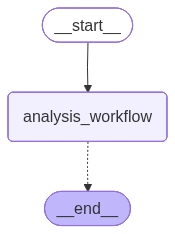

In [21]:
# ---------------------------------------------------
# 3-4. LangGraph 기본 그래프 시각화 (참고)
# ---------------------------------------------------
# get_graph()가 그려주는 기본 구조는 entrypoint 수준의 실행 그래프예요.
# @task 결과 캐싱/replay 차이는 위의 3-1-E/F, 3-2-E/F 시각화를 함께 보세요.
from IPython.display import Image, display

display(Image(analysis_workflow.get_graph().draw_mermaid_png()))


## 4. execution_info - 재시도 정보 접근

RetryPolicy로 재시도 중에 현재 시도 횟수나 첫 시도 시각을 알고 싶을 때가 있어요.
LangGraph 1.1.3 이상에서는 `get_store()` 또는 노드 파라미터를 통해
실행 정보(`execution_info`)에 접근할 수 있어요.

> ⚠️ **주의**: 재시도 메타데이터(`node_attempt`, `node_first_attempt_time`)는 LangGraph 내부 메타데이터로, 버전에 따라 키 이름·접근 방식이 달라질 수 있어요. 공식 API로 보증된 값이 아니므로 프로덕션에서는 자체 카운터를 병행하는 것을 권장해요.

> 🎯 **강의 포인트**: `node_attempt`와 `node_first_attempt_time`을 활용하면
> 로그에 재시도 컨텍스트를 포함시켜 모니터링을 개선할 수 있어요.
> 예를 들어 "이 요청이 몇 번째 재시도인가?"를 알면 알림 임계값 조정이 가능해요.

In [22]:
# ---------------------------------------------------
# RunnableConfig를 통한 실행 정보 접근
# ---------------------------------------------------
# LangGraph >=1.1.3: config에서 execution_info 접근 가능
# node_attempt: 현재 몇 번째 시도인지 (0부터 시작)
# node_first_attempt_time: 처음 시도 시각
from langchain_core.runnables import RunnableConfig
from datetime import datetime

attempt_info_log = []


def monitored_node(state: WorkflowState, config: RunnableConfig) -> WorkflowState:
    """실행 정보를 로깅하는 노드예요"""
    # config에서 execution_info 추출 (LangGraph >=1.1.3)
    execution_info = config.get("metadata", {})

    # langgraph 내부 메타데이터에서 재시도 정보 읽기
    node_attempt = config.get("metadata", {}).get("node_attempt", 0)
    first_attempt_time = config.get("metadata", {}).get(
        "node_first_attempt_time",
        datetime.now().isoformat()
    )

    log_entry = {
        "attempt": node_attempt,
        "timestamp": datetime.now().isoformat(),
    }
    attempt_info_log.append(log_entry)

    print(f"  [Monitored Node] 시도 #{node_attempt}, 시각: {log_entry['timestamp'][:19]}")

    return {
        "step": 1,
        "result": state["result"] + [f"모니터링된 노드 완료 (시도 #{node_attempt})"]
    }


# execution_info 접근 예시 그래프
monitor_builder = StateGraph(WorkflowState)
monitor_builder.add_node("monitored", monitored_node)
monitor_builder.add_edge(START, "monitored")
monitor_builder.add_edge("monitored", END)

monitor_graph = monitor_builder.compile(checkpointer=InMemorySaver())

monitor_config = {"configurable": {"thread_id": str(uuid.uuid4())}}
monitor_result = monitor_graph.invoke({"step": 0, "result": []}, monitor_config)

print(f"\n실행 로그: {attempt_info_log}")
print(f"결과: {monitor_result['result']}")


  [Monitored Node] 시도 #0, 시각: 2026-05-27T10:00:22

실행 로그: [{'attempt': 0, 'timestamp': '2026-05-27T10:00:22.531126'}]
결과: ['모니터링된 노드 완료 (시도 #0)']


> 💡 **실무 팁**: `node_attempt` 값에 따라 경보(alert) 전략을 달리할 수 있어요.
> - 1회 재시도: INFO 로그만 기록
> - 2회 재시도: WARNING 로그 + 슬랙 알림
> - 최대 재시도 도달: ERROR 로그 + 온콜(on-call) 알림

## 5. 멱등성 키(Idempotency Key)

외부 API를 재시도할 때 중복 호출 문제가 생길 수 있어요.
예를 들어 결제 API를 재시도하면 이중 결제가 발생할 수 있죠.

**멱등성 키(Idempotency Key)**를 사용하면 서버가 동일한 요청임을 인식하고
이전 결과를 반환하도록 할 수 있어요.

> 🔑 **핵심 개념**: 멱등성(Idempotency)은 "같은 요청을 여러 번 보내도 결과가 동일하다"는 속성이에요.
> 대부분의 결제 API(Stripe, PayPal 등)와 메시지 큐(SQS 등)가 멱등성 키를 지원해요.

In [23]:
# ---------------------------------------------------
# 멱등성 키 패턴
# ---------------------------------------------------
# thread_id + 노드명 조합으로 유니크한 멱등성 키 생성
# 재시도 시 같은 키를 사용하면 중복 처리를 방지할 수 있어요
import hashlib


def generate_idempotency_key(thread_id: str, node_name: str, operation: str) -> str:
    """재현 가능한 멱등성 키를 생성해요.

    같은 thread_id + node_name + operation 조합은
    항상 동일한 키를 생성해요.
    """
    payload = f"{thread_id}:{node_name}:{operation}"
    return hashlib.sha256(payload.encode()).hexdigest()[:16]


def payment_node(state: WorkflowState, config: RunnableConfig) -> WorkflowState:
    """결제 처리 노드 - 멱등성 키로 중복 결제 방지해요"""
    thread_id = config["configurable"]["thread_id"]

    # 멱등성 키 생성: thread_id가 같으면 항상 같은 키
    idempotency_key = generate_idempotency_key(
        thread_id=thread_id,
        node_name="payment",
        operation="charge_user"
    )

    print(f"  [Payment] 멱등성 키: {idempotency_key}")
    print(f"  [Payment] 결제 API 호출 중... (키가 같으면 중복 결제 방지)")

    # 실제로는 payment_api.charge(amount=1000, idempotency_key=idempotency_key)
    # 재시도해도 서버에서 중복 처리 방지

    return {
        "step": 1,
        "result": state["result"] + [f"결제 완료 (멱등성 키: {idempotency_key})"],
    }


payment_builder = StateGraph(WorkflowState)
payment_builder.add_node("payment", payment_node)
payment_builder.add_edge(START, "payment")
payment_builder.add_edge("payment", END)

payment_graph = payment_builder.compile(checkpointer=InMemorySaver())

# 같은 thread_id로 두 번 실행해도 같은 멱등성 키 생성
payment_config = {"configurable": {"thread_id": "fixed-thread-for-demo"}}

# === 1차 결제 시도 ===
r1 = payment_graph.invoke({"step": 0, "result": []}, payment_config)
print(f"결과: {r1['result']}")

# === 2차 결제 시도 (동일 thread_id - 같은 멱등성 키 확인) ===
r2 = payment_graph.invoke({"step": 0, "result": []}, payment_config)
print(f"결과: {r2['result']}")

  [Payment] 멱등성 키: c31eb6e1993af0d4
  [Payment] 결제 API 호출 중... (키가 같으면 중복 결제 방지)
결과: ['결제 완료 (멱등성 키: c31eb6e1993af0d4)']
  [Payment] 멱등성 키: c31eb6e1993af0d4
  [Payment] 결제 API 호출 중... (키가 같으면 중복 결제 방지)
결과: ['결제 완료 (멱등성 키: c31eb6e1993af0d4)']


## 6. SqliteSaver - 영구 저장 체크포인터

`InMemorySaver`는 프로세스가 종료되면 모든 체크포인트가 사라져요.
프로세스 재시작 후에도 재개하려면 **파일 기반 또는 DB 기반 체크포인터**가 필요해요.

> 💡 **실무 팁**: 개발 및 소규모 로컬 배포에는 `SqliteSaver`, 프로덕션 멀티 인스턴스 환경에는 `PostgresSaver`를 사용해요.
> 전환할 때 코드 변경은 최소화돼요. Checkpointer만 교체하면 나머지 로직은 동일해요.

In [24]:
# ---------------------------------------------------
# SqliteSaver를 사용한 영구 체크포인트
# ---------------------------------------------------
# 설치: pyproject.toml의 langgraph-checkpoint-sqlite 의존성으로 제공돼요.
import tempfile
import os

from langgraph.checkpoint.sqlite import SqliteSaver

# 임시 SQLite 파일 생성
db_path = os.path.join(tempfile.gettempdir(), "langgraph_durable_demo.db")
print(f"SQLite DB 경로: {db_path}")

# SqliteSaver는 컨텍스트 매니저로 사용해요
with SqliteSaver.from_conn_string(db_path) as sqlite_checkpointer:
    # 기존 그래프와 동일하게 checkpointer만 교체
    sqlite_graph = builder.compile(checkpointer=sqlite_checkpointer)

    sqlite_config = {"configurable": {"thread_id": "sqlite-persistent-thread"}}

    # === SqliteSaver 그래프 실행 ===
    result = sqlite_graph.invoke(
        {"step": 0, "result": []},
        sqlite_config
    )
    print(f"결과: {result['result']}")

    # 상태 확인
    saved_state = sqlite_graph.get_state(sqlite_config)
    print(f"저장된 상태: step={saved_state.values.get('step')}")

# 컨텍스트 종료 후에도 DB 파일에 체크포인트가 저장되어 있어요.
print(f"파일 크기: {os.path.getsize(db_path)} bytes")


SQLite DB 경로: /var/folders/14/3sq03f6s3_7bs0tygfqqvc_c0000gn/T/langgraph_durable_demo.db
결과: ['Step1: 데이터 수집 완료', 'Step2: 데이터 처리 완료', 'Step3: 결과 저장 완료']
저장된 상태: step=3
파일 크기: 28672 bytes


## 7. TODO 실습: 장애 복구 시나리오 설계

아래 코드는 3단계 데이터 파이프라인이에요.
여러분이 직접 RetryPolicy와 재개 로직을 완성해보세요.

In [25]:
# ============================================================
# 구현 예시: 데이터 파이프라인에 내구성 실행 추가
# ============================================================
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import RetryPolicy
from langgraph.checkpoint.memory import InMemorySaver
import uuid


class ETLState(TypedDict):
    data: list[dict]
    status: str


extract_attempts = 0


def extract_node(state: ETLState) -> ETLState:
    """데이터 추출 노드 - 처음 한 번은 ConnectionError 발생."""
    global extract_attempts
    extract_attempts += 1
    print(f"  [Extract] 시도 #{extract_attempts}")

    if extract_attempts == 1:
        raise ConnectionError("원격 서버에 연결할 수 없어요")

    return {"data": [{"id": i, "value": i * 10} for i in range(3)], "status": "extracted"}


def transform_node(state: ETLState) -> ETLState:
    """데이터 변환 노드."""
    print("  [Transform] 데이터 변환 중...")
    transformed = [{**d, "value": d["value"] * 2} for d in state["data"]]
    return {"data": transformed, "status": "transformed"}


def load_node(state: ETLState) -> ETLState:
    """데이터 저장 노드."""
    print("  [Load] 데이터 저장 중...")
    return {"data": state["data"], "status": "loaded"}


etl_builder = StateGraph(ETLState)

etl_builder.add_node(
    "extract",
    extract_node,
    retry=RetryPolicy(
        max_attempts=3,
        initial_interval=0.1,
        backoff_factor=2.0,
        retry_on=(ConnectionError,),
    ),
)
etl_builder.add_node("transform", transform_node)
etl_builder.add_node(
    "load",
    load_node,
    retry=RetryPolicy(
        max_attempts=2,
        initial_interval=0.1,
        retry_on=(TimeoutError,),
    ),
)

etl_builder.add_edge(START, "extract")
etl_builder.add_edge("extract", "transform")
etl_builder.add_edge("transform", "load")
etl_builder.add_edge("load", END)

etl_graph = etl_builder.compile(checkpointer=InMemorySaver())

print("=== ETL 파이프라인 실행 ===")
extract_attempts = 0
etl_config = {"configurable": {"thread_id": str(uuid.uuid4())}}
etl_result = etl_graph.invoke({"data": [], "status": ""}, etl_config)

print(f"\n최종 상태: {etl_result['status']}")
print(f"처리된 데이터: {etl_result['data']}")


=== ETL 파이프라인 실행 ===
  [Extract] 시도 #1
  [Extract] 시도 #2
  [Transform] 데이터 변환 중...
  [Load] 데이터 저장 중...

최종 상태: loaded
처리된 데이터: [{'id': 0, 'value': 0}, {'id': 1, 'value': 20}, {'id': 2, 'value': 40}]


<details>
<summary>정답 보기 (직접 해결 후 확인하세요)</summary>

```python
# TODO 1: extract_node - ConnectionError 재시도
etl_builder.add_node(
    "extract",
    extract_node,
    retry=RetryPolicy(
        max_attempts=3,
        initial_interval=0.1,
        backoff_factor=2.0,
        retry_on=lambda e: isinstance(e, ConnectionError),
    )
)

# TODO 2: transform_node - 재시도 없음
etl_builder.add_node("transform", transform_node)

# TODO 3: load_node - TimeoutError 재시도
etl_builder.add_node(
    "load",
    load_node,
    retry=RetryPolicy(
        max_attempts=2,
        retry_on=lambda e: isinstance(e, TimeoutError),
    )
)

# TODO 4: InMemorySaver로 컴파일
etl_graph = etl_builder.compile(checkpointer=InMemorySaver())
```
</details>

## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **내구성 실행(Durable Execution)**: Checkpointer + thread_id + 결정론성 세 가지 요소로 구현해요. 장애 발생 시 처음부터 재시작하지 않고 중단점에서 재개해요.
- **Durability Mode**: `"exit"`(기본), `"async"`, `"sync"` 세 가지 모드로 체크포인트 생성 시점을 제어해요.
- **장애 재개 패턴**: `graph.invoke(None, config)`에 동일 `thread_id`를 사용하면 자동으로 마지막 체크포인트에서 이어가요.
- **RetryPolicy**: `max_attempts`, `initial_interval`, `backoff_factor`, `jitter`, `retry_on` 파라미터로 자동 재시도를 구성해요. `ValueError`, `TypeError` 등 프로그래밍 오류는 기본적으로 재시도하지 않아요.
- **@task + @entrypoint**: Functional API에서 사이드 이펙트를 격리하는 패턴이에요. `@task` 결과는 캐시되어 재개 시 재실행되지 않아요.
- **멱등성 키**: thread_id + 노드명 + 연산 조합으로 재현 가능한 키를 만들어 외부 API 중복 호출을 방지해요.
- **Checkpointer 종류**: `InMemorySaver`(개발), `SqliteSaver`(로컬), `PostgresSaver`(프로덕션)을 용도에 맞게 선택해요.


## 다음 노트북 예고

다음 `05-DeleteMessages.ipynb`에서는 **`RemoveMessage`로 컨텍스트 윈도우 최적화**를 배워요. 대화가 길어질수록 토큰 비용과 지연이 늘어나는데, 메시지 ID를 지정해 불필요한 과거 메시지를 정밀하게 삭제하는 방법을 다뤄요. 오늘 배운 체크포인터에 쌓이는 상태를 효과적으로 관리하는 후속 기법이에요.